<a href="https://colab.research.google.com/github/Md819-max/BTC-price-predict/blob/main/Silver_price_Forecast_Jan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# DIGITAL SILVER PRICE FORECAST (FEB 2026)
# Instrument : COMEX Silver Futures (SI=F)
# Output     : INR per gram
# Model      : LSTM (monthly log returns)
# =========================================================

# -----------------------------
# 1. Imports
# -----------------------------
import yfinance as yf
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# -----------------------------
# 2. Parameters
# -----------------------------
TICKER = "SI=F"
START_DATE = "2010-01-01"
END_DATE = "2026-01-31"      # include Jan 2026 so Feb 2026 is next
WINDOW = 12

USD_INR = 83.0               # assumed FX
GRAMS_PER_OZ = 31.1035


# -----------------------------
# 3. Load Data (Digital / Spot-linked Silver)
# -----------------------------
df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False
)

df.dropna(inplace=True)


# -----------------------------
# 4. Convert to Monthly Close
# -----------------------------
monthly_close = df["Close"].resample("ME").last()
monthly_close.dropna(inplace=True)

print("Last available month:", monthly_close.index[-1])


# -----------------------------
# 5. Log Returns
# -----------------------------
log_returns = np.log(monthly_close / monthly_close.shift(1))
log_returns.dropna(inplace=True)


# -----------------------------
# 6. Scale Returns
# -----------------------------
scaler = MinMaxScaler()
scaled_returns = scaler.fit_transform(log_returns.values.reshape(-1, 1))


# -----------------------------
# 7. Create Sequences
# -----------------------------
X, y = [], []

for i in range(WINDOW, len(scaled_returns)):
    X.append(scaled_returns[i-WINDOW:i])
    y.append(scaled_returns[i])

X, y = np.array(X), np.array(y)


# -----------------------------
# 8. LSTM Model
# -----------------------------
model = Sequential([
    LSTM(50, activation="tanh", input_shape=(WINDOW, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=30, batch_size=16, verbose=0)


# -----------------------------
# 9. Predict NEXT MONTH (FEB 2026)
# -----------------------------
last_window = scaled_returns[-WINDOW:].reshape(1, WINDOW, 1)

pred_scaled = model.predict(last_window, verbose=0)
pred_log_return = scaler.inverse_transform(pred_scaled)[0, 0]


# -----------------------------
# 10. Reconstruct Price (USD / oz)
# -----------------------------
last_price_usd_oz = monthly_close.iloc[-1]
pred_price_usd_oz = last_price_usd_oz * np.exp(pred_log_return)


# -----------------------------
# 11. Convert to INR per gram
# -----------------------------
pred_price_inr_gram = (pred_price_usd_oz * USD_INR) / GRAMS_PER_OZ


# -----------------------------
# 12. Final Output
# -----------------------------
print("\n📌 TARGET MONTH : FEBRUARY 2026")
print(f"Predicted Silver Price (USD / oz): {pred_price_usd_oz.item():.2f}")
print(f"Predicted Digital Silver Price (INR / gram): ₹{pred_price_inr_gram.item():.2f}")

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Last available month: 2026-01-31 00:00:00

📌 TARGET MONTH : FEBRUARY 2026
Predicted Silver Price (USD / oz): 100.03
Predicted Digital Silver Price (INR / gram): ₹266.94


In [2]:
#Expect for return posssible
print(f"Predicted feb  2026 log return: {pred_log_return:.4%}")
print(f"Predicted feb 2026 Silver Price: {pred_price_usd_oz.item():.2f}")

Predicted feb  2026 log return: 5.9558%
Predicted feb 2026 Silver Price: 100.03


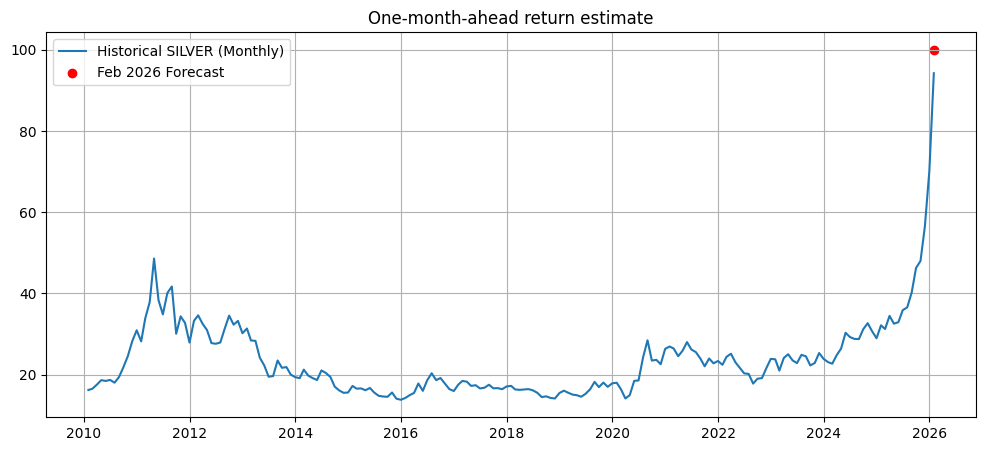

In [3]:
#Visualizations

import matplotlib.pyplot as plt

#Visual (Monthly – Correct Way)
plt.figure(figsize=(12,5))
plt.plot(monthly_close.index, monthly_close.values, label="Historical SILVER (Monthly)")
plt.scatter(pd.Timestamp("2026-01-31"), pred_price_usd_oz, color='red', label="Feb 2026 Forecast")
plt.legend()
plt.title("One-month-ahead return estimate")
plt.grid(True)
plt.show()